In [3]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
n_samples=1000
temperature=np.random.randint(120,240,n_samples)
time=np.random.randint(5,26,n_samples)
X=np.column_stack((temperature,time))
y=[]
for temp,t in zip(temperature,time):
    if(temp>140 and temp<220 and t>10 and t<20):
        y.append(1)
    else:
        y.append(0)
y=np.array(y)
print("X Shape:",X.shape)
print("y Shape:",y.shape)

print(X[:10])
print(y[:10])

X Shape: (1000, 2)
y Shape: (1000,)
[[222  17]
 [171  17]
 [212   8]
 [134   5]
 [226  21]
 [191  12]
 [180   6]
 [140  12]
 [222  11]
 [202   6]]
[0 1 0 0 0 1 0 0 0 0]


In [4]:
X_norm=X.copy().astype(float)
X_norm[:,0]=X_norm[:,0]/250
X_norm[:,1]=X_norm[:,1]/26
print(X_norm[:10])

[[0.888      0.65384615]
 [0.684      0.65384615]
 [0.848      0.30769231]
 [0.536      0.19230769]
 [0.904      0.80769231]
 [0.764      0.46153846]
 [0.72       0.23076923]
 [0.56       0.46153846]
 [0.888      0.42307692]
 [0.808      0.23076923]]


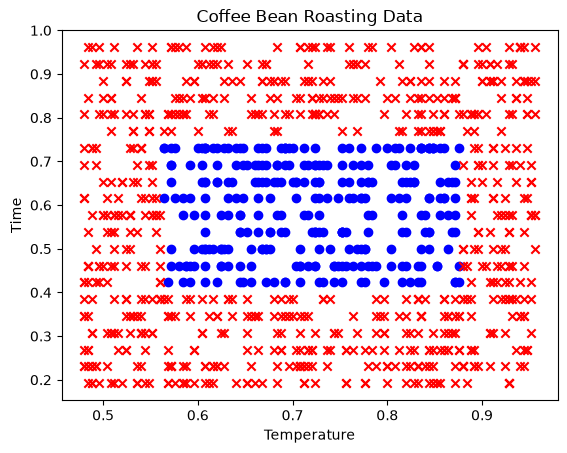

In [5]:
for i in range(len(X_norm)):
    if y[i]==1:
        plt.scatter(X_norm[i,0],X_norm[i,1],color='blue',marker='o')
    else:
        plt.scatter(X_norm[i,0],X_norm[i,1],color='red',marker='x')
plt.xlabel("Temperature")
plt.ylabel("Time")
plt.title("Coffee Bean Roasting Data")   
plt.show()

Epoch 1/300


c:\Users\durga\.conda\envs\tfenv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5900 - loss: 0.6710 
Epoch 2/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7140 - loss: 0.6078
Epoch 3/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7140 - loss: 0.5992 
Epoch 4/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7140 - loss: 0.5969 
Epoch 5/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7140 - loss: 0.5945 
Epoch 6/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7140 - loss: 0.5918 
Epoch 7/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7140 - loss: 0.5905 
Epoch 8/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7140 - loss: 0.5845 
Epoch 9/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7140 - loss: 0.5781 
Epoch 10/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7140 - loss: 0.5713 
Epoch 11/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7140 - loss: 0.5645 
Epoch 12/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0

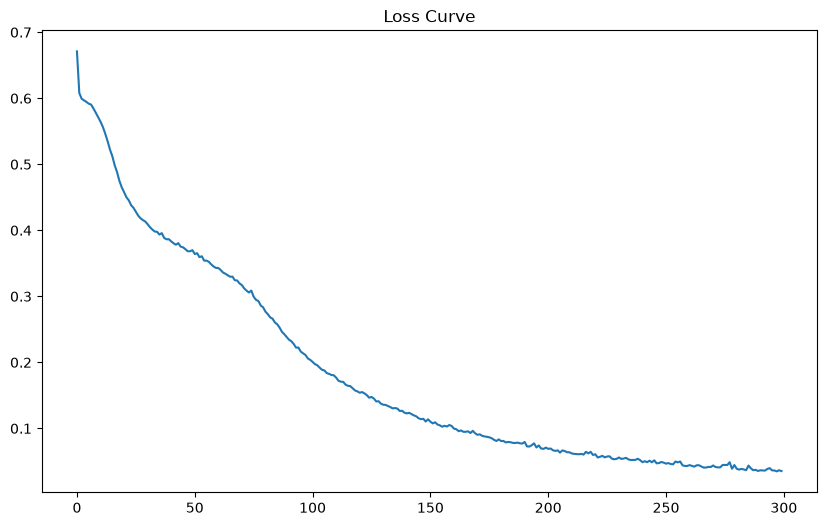

TypeError: 'str' object is not callable

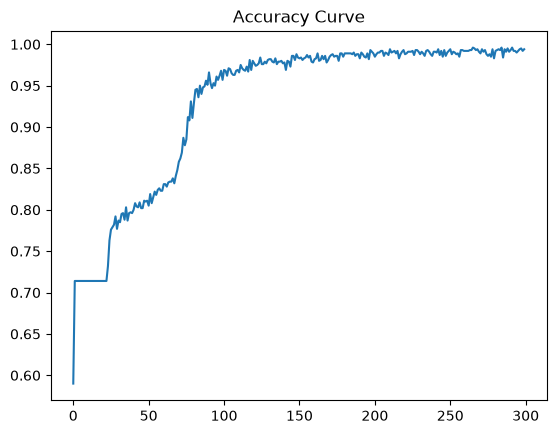

In [6]:
import tensorflow as tf

model = tf.keras.Sequential([

    tf.keras.layers.Dense(
        64,
        activation='relu',
        input_shape=(2,)
    ),

    tf.keras.layers.Dense(
        32,
        activation='relu'
    ),

    tf.keras.layers.Dense(
        1,
        activation='sigmoid'
    )
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.fit(X_norm,y,epochs=300,verbose=1)
plt.figure(figsize=(10,6))
plt.plot(model.history.history['loss'],label='Loss')
plt.xlabel="Epochs"
plt.ylabel="Loss"
plt.title("Loss Curve")
plt.show()
plt.plot(model.history.history['accuracy'])
plt.title('Accuracy Curve')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()


In [7]:
loss, accuracy = model.evaluate(X_norm, y)

print("Loss:", loss)
print("Accuracy:", accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9950 - loss: 0.0329 
Loss: 0.03285866603255272
Accuracy: 0.9950000047683716


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_norm,
    y,
    test_size=0.2,
    random_state=42
)
history = model.fit(
    X_train,
    y_train,
    epochs=300,
    verbose=1
)
loss, acc = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", acc)


Epoch 1/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9950 - loss: 0.0330 
Epoch 2/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9937 - loss: 0.0347 
Epoch 3/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9912 - loss: 0.0343 
Epoch 4/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9912 - loss: 0.0354 
Epoch 5/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9950 - loss: 0.0335 
Epoch 6/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9937 - loss: 0.0316 
Epoch 7/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9950 - loss: 0.0313 
Epoch 8/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9975 - loss: 0.0314 
Epoch 9/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9937 - loss: 0.0323 
Epoch 10/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9950 - loss: 0.0312 
Epoch 11/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9912 - loss: 0.0346 
Epoch 12/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

In [10]:
from sklearn.metrics import confusion_matrix
new_bean = np.array([[220, 15]])
new_bean_norm = new_bean / X.max(axis=0)

prediction = model.predict(new_bean_norm)
print(prediction)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
[[0.0063851]]


In [11]:
beans = np.array([
    [180,10],
    [200,15],
    [220,18],
    [240,20]
])

beans_norm = beans / X.max(axis=0)

pred = model.predict(beans_norm)

for bean, p in zip(beans, pred):
    print(bean, " -> ", p[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
[180  10]  ->  0.9098849
[200  15]  ->  0.994279
[220  18]  ->  0.021365806
[240  20]  ->  8.745507e-09


In [12]:
model.save("coffee_roasting_model.keras")

In [13]:
from tensorflow.keras.models import load_model

model = load_model("coffee_roasting_model.keras")